In [30]:
import geohexgrid as ghg
import numpy as np
from shapely import Polygon, LineString, LinearRing, Point, MultiPoint, GeometryCollection
import geopandas as gpd
import pandas as pd
from math import comb
import numpy as np
import matplotlib.pyplot as plt
import collections
from typing import List, Tuple

## Get the shape of some city

  id                                     geometry
0  1  POLYGON ((0 0, 0 100, 100 100, 100 0, 0 0))


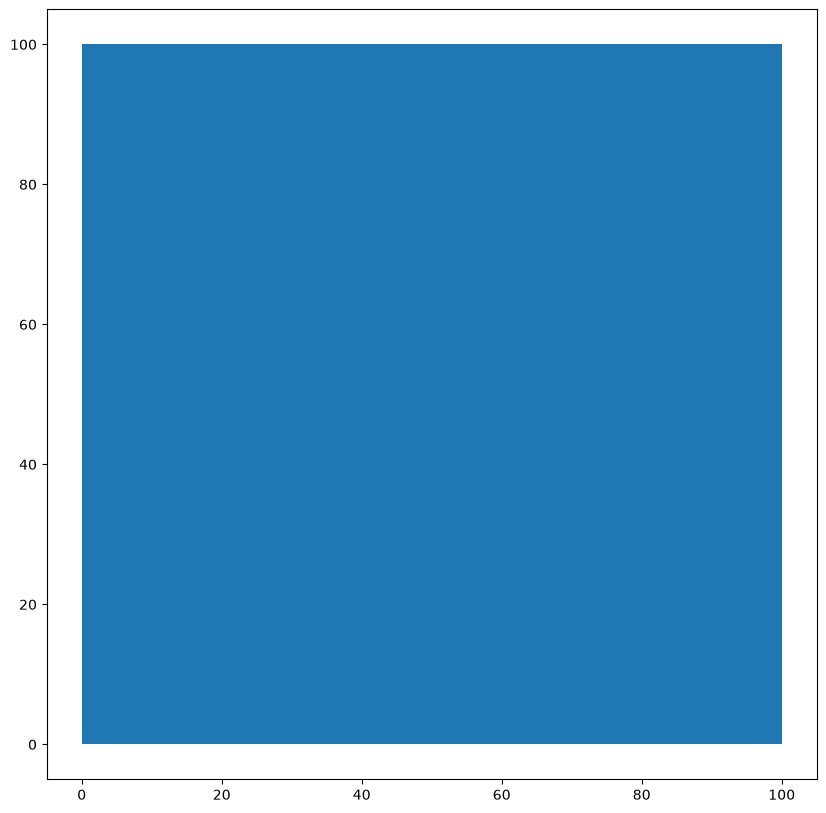

In [31]:
d = {'id': ['1'], 'geometry': [Polygon([(0., 0.), (0., 100.), (100., 100.), (100., 0.)])]}
base = gpd.GeoDataFrame(data=d, crs=None)
background = base.plot(figsize=(10, 10))
print(base)

## Create hex grid

<Axes: >

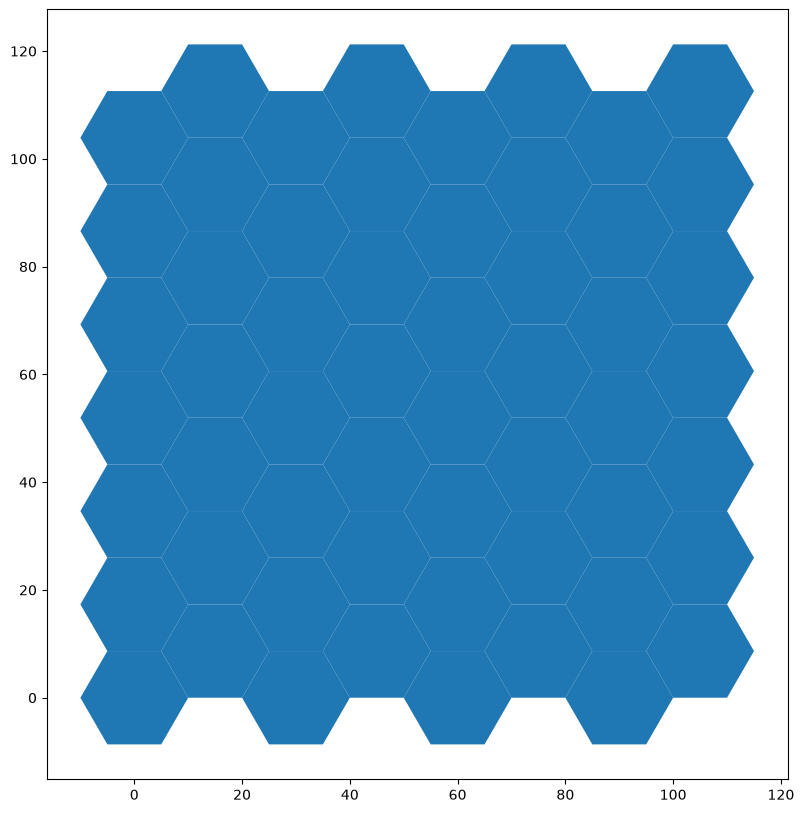

In [32]:
grid = ghg.make_grid_from_bounds(0., 0., 100., 100., R=10.)
grid.plot(figsize=(10, 10))

In [33]:
type(grid)

geopandas.geodataframe.GeoDataFrame

In [34]:
hex_example = grid.iat[0,-1]
hex_example
print(hex_example)

POLYGON ((-5 -8.660254037844386, 5 -8.660254037844386, 10 0, 5 8.660254037844386, -5 8.660254037844386, -10 0, -5 -8.660254037844386))


In [35]:
print(f"area: {hex_example.area}")
print(f"boundary: {hex_example.boundary}")
print(f"bounds: {hex_example.bounds}")
print(f"centroid: {hex_example.centroid}")

area: 259.80762113533154
boundary: LINESTRING (-5 -8.660254037844386, 5 -8.660254037844386, 10 0, 5 8.660254037844386, -5 8.660254037844386, -10 0, -5 -8.660254037844386)
bounds: (-10.0, -8.660254037844386, 10.0, 8.660254037844386)
centroid: POINT (1.4586028080420515e-16 0)


## Extract seed points

In [36]:
grid['centroid'] = grid['geometry'].centroid
grid.head()

,cell_id,geometry,centroid
0,"0,0","POLYGON ((-5 -8.66025, 5 -8.66025, 10 0, 5 8.6...",POINT (1.4586e-16 0)
1,"1,1","POLYGON ((10 0, 20 0, 25 8.66025, 20 17.32051,...",POINT (15 8.66025)
2,"2,0","POLYGON ((25 -8.66025, 35 -8.66025, 40 0, 35 8...",POINT (30 0)
3,"3,1","POLYGON ((40 0, 50 0, 55 8.66025, 50 17.32051,...",POINT (45 8.66025)
4,"4,0","POLYGON ((55 -8.66025, 65 -8.66025, 70 0, 65 8...",POINT (60 0)


<Axes: >

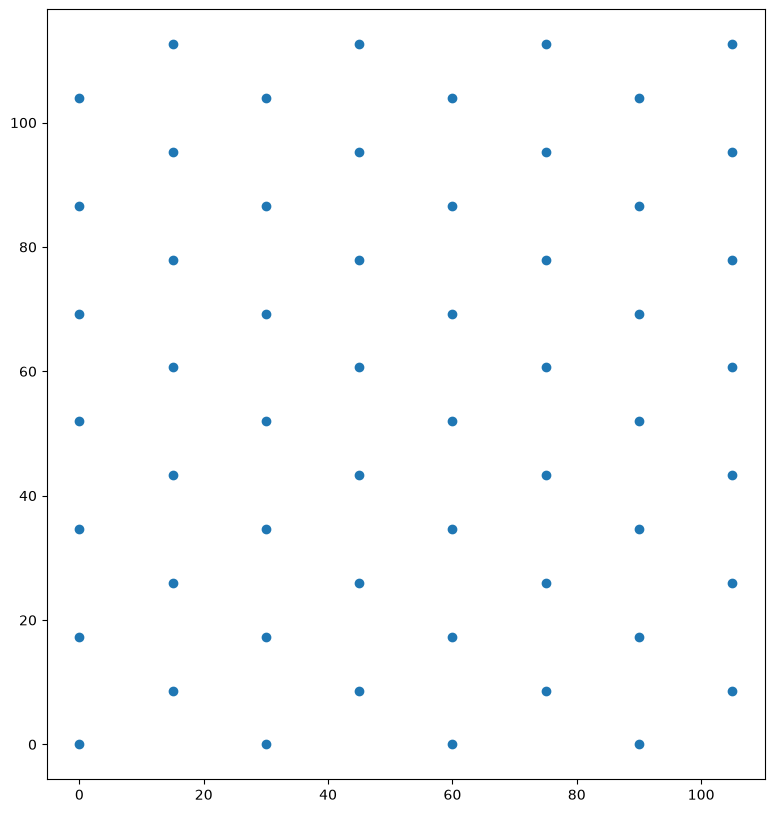

In [37]:
centroids = grid["centroid"]
centroids.plot(figsize=(10, 10))

## Create demand matrix

### Compute seed point pairs

no. of seed points: 56
no. of pairs is actually: 1540
no. of pairs should be: 1540


<Axes: >

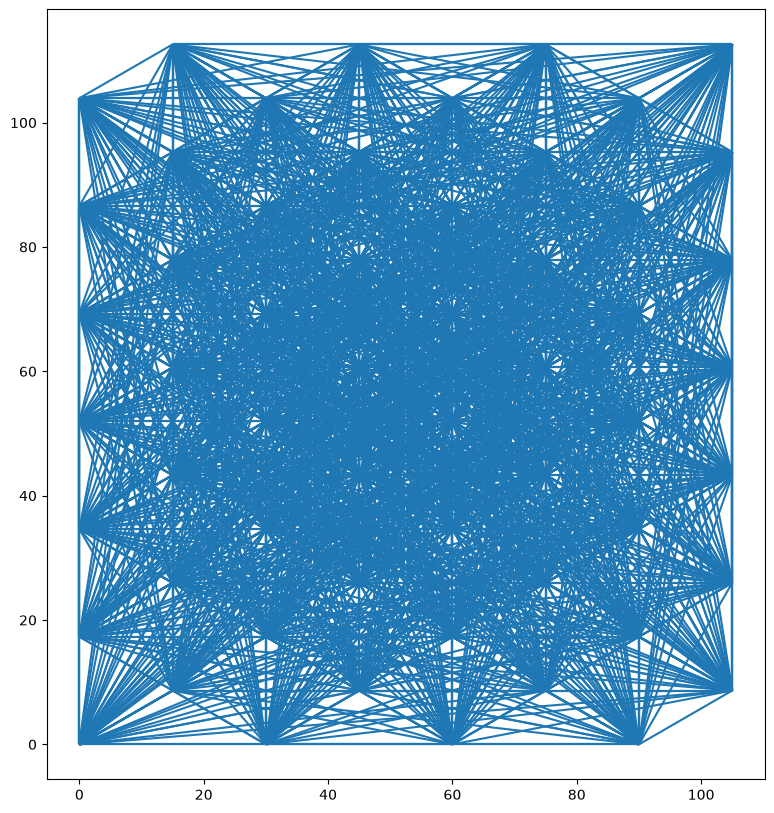

In [38]:
def od_pairs(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    seed_points = gdf['cell_id'].values.tolist()
    geo = gdf['centroid'].values.tolist()
    n = len(seed_points)
    ids = []
    origins = []
    dests = []
    lines = []
    for i in range(n):
        for j in range(i+1, n):
            # print(f'seed_points[i]: {seed_points[i]}, seed_points[j]: {seed_points[j]}')
            # print(f'geo[i]: {geo[i]}, geo[j]: {geo[j]}')
            ids.append((seed_points[i], seed_points[j]))
            origins.append(seed_points[i])
            dests.append(seed_points[j])
            lines.append(LineString([geo[i], geo[j]]))
    return gpd.GeoDataFrame({'pair': ids, 'u': origins, 'v': dests, 'geometry': lines})

test_pairs = od_pairs(grid)
print(f'no. of seed points: {grid.shape[0]}')
print(f'no. of pairs is actually: {test_pairs.shape[0]}')
print(f'no. of pairs should be: {comb(grid.shape[0], 2)}')
test_pairs.head()
test_pairs.plot(figsize=(10, 10))

### Generate random demand

In [39]:
def generate_demand(mean: float, std: float, n: int) -> np.ndarray:
    seed: int = 8920299146682435938
    rng: np.random.Generator = np.random.default_rng(seed=seed)
    return rng.normal(mean, std, size=n)

# Code from NumPy docs
def plot_demand_distribution(mean: float, std: float, demand: np.ndarray):
    count, bins, _ = plt.hist(demand, 30, density=True)
    plt.plot(bins, 1/(std * np.sqrt(2 * np.pi)) *
                   np.exp( - (bins - mean)**2 / (2 * std**2) ),
             linewidth=2, color='r')
    plt.show()

#TODO: MAKE THE DEMAND DISTRIBUTION WEIRD
#for report: demand could also be made proportional to popylation density. but for now this is our proxy 

In [40]:
P = test_pairs.shape[0] # number of seed point pairs
mean: float = 1.0
std: float = 0.2
test_demand = generate_demand(mean, std, P)
print(type(test_demand))
print(len(test_demand))
print(len(test_demand))
test_demand

<class 'numpy.ndarray'>
1540
1540


array([0.83244838, 0.85595253, 0.93743583, ..., 1.08132355, 1.09512595,
       0.84928685], shape=(1540,))

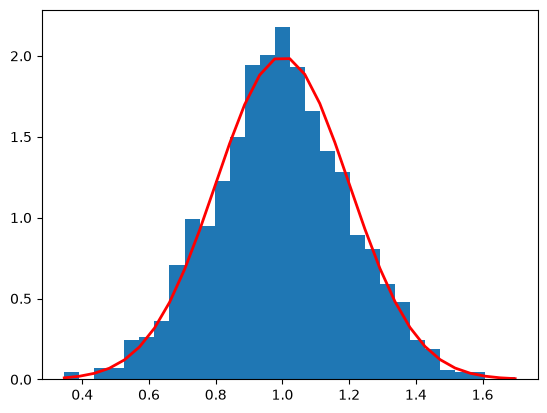

In [41]:
plot_demand_distribution(mean, std, test_demand)

In [42]:
demand_matrix = pd.concat([test_pairs, pd.Series(test_demand)], axis=1)
demand_matrix.columns = ['pair', 'u', 'v', 'geometry', 'demand']
demand_matrix.head()
demand_matrix.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1540 entries, 0 to 1539
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pair      1540 non-null   object  
 1   u         1540 non-null   str     
 2   v         1540 non-null   str     
 3   geometry  1540 non-null   geometry
 4   demand    1540 non-null   float64 
dtypes: float64(1), geometry(1), object(1), str(2)
memory usage: 70.2+ KB


In [43]:
ordered_demand = demand_matrix.sort_values(by=['demand', 'pair'], ascending=False)
ordered_demand.head()

,pair,u,v,geometry,demand
99,"(1,1, 6,10)","1,1","6,10","LINESTRING (15 8.66025, 90 86.60254)",1.697672
853,"(2,4, 3,9)","2,4","3,9","LINESTRING (30 34.64102, 45 77.94229)",1.579520
1277,"(0,8, 6,10)","0,8","6,10","LINESTRING (1.4586e-16 69.28203, 90 86.60254)",1.573304
140,"(2,0, 2,8)","2,0","2,8","LINESTRING (30 0, 30 69.28203)",1.571054
385,"(7,1, 5,7)","7,1","5,7","LINESTRING (105 8.66025, 75 60.62178)",1.532753


## Calculate total demand

In [44]:
total_demand = float(demand_matrix['demand'].sum())
total_demand

1530.2849654527618

In [45]:
demand_matrix["demand_share"] = demand_matrix["demand"] * 100 / total_demand

Text(0.5, 1.0, 'Seed point pairs')

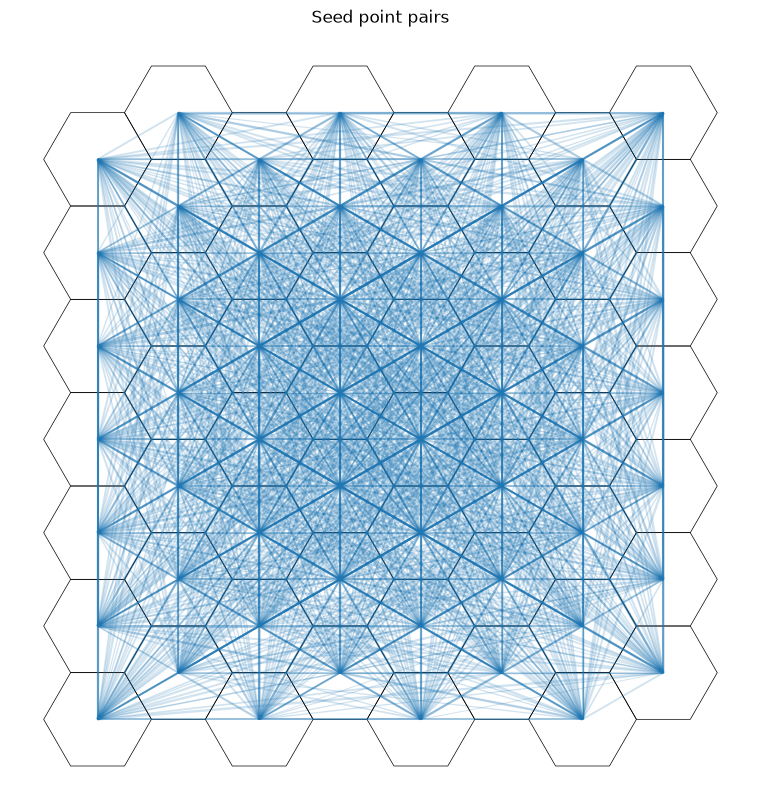

In [46]:
# With Anastassia's plot:

fig, ax = plt.subplots(1,1, figsize = (10,10))
grid.boundary.plot(ax=ax, color = "black", zorder = 0, lw = 0.5)
#grid.boundary.plot(column="centroid", ax=ax, alpha=0.5, color = "orange", label="seed points", markersize = 2, zorder = 1)
#test_pairs.plot(column='u', ax=ax, alpha=0.5, color = "blue", label = "origins", markersize = 2, zorder = 1)
#test_pairs.plot(column='v', ax=ax, alpha=0.5, color = "orange", label = "destinations", markersize = 2, zorder = 2)
demand_matrix.plot(ax=ax, lw = demand_matrix.demand_share * 20, alpha = 0.2)
ax.set_axis_off()
ax.set_title("Seed point pairs")


In [47]:
seed_points = grid
seed_points.columns = ['id', 'geometry', 'centroid']
seed_points.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   id        56 non-null     str     
 1   geometry  56 non-null     geometry
 2   centroid  56 non-null     geometry
dtypes: geometry(2), str(1)
memory usage: 1.6 KB


In [48]:
seed_points["total_demand"] = seed_points.apply(
    lambda x:
        sum(demand_matrix[(demand_matrix.u == x.id) | (demand_matrix.v == x.id)].demand),
    axis = 1
)
seed_points.sort_values('total_demand', ascending=False).head()

,id,geometry,centroid,total_demand
35,"3,9","POLYGON ((40 69.282, 50 69.282, 55 77.942, 50 ...",POINT (45 77.942),57.849538
24,"0,6","POLYGON ((-5 43.301, 5 43.301, 10 51.962, 5 60...",POINT (-1.459e-16 51.962),57.356001
8,"0,2","POLYGON ((-5 8.66, 5 8.66, 10 17.321, 5 25.981...",POINT (1.459e-16 17.321),57.068446
47,"7,11","POLYGON ((100 86.603, 110 86.603, 115 95.263, ...",POINT (105 95.263),56.978715
55,"7,13","POLYGON ((100 103.923, 110 103.923, 115 112.58...",POINT (105 112.583),56.601550


Text(0.5, 1.0, 'Total demand per hexagon')

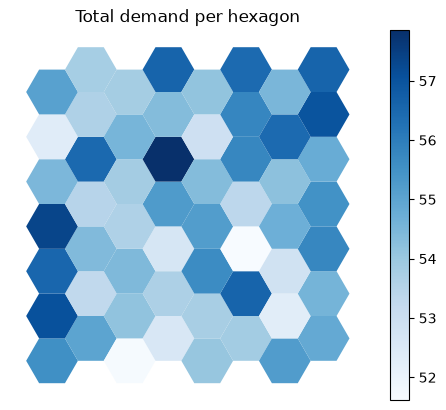

In [49]:

fig, ax = plt.subplots(1,1)
seed_points.plot(
    ax=ax,
    column="total_demand",
    cmap = "Blues",
    legend=True
)
ax.set_axis_off()
ax.set_title("Total demand per hexagon")

## Genetic Algorithm

We currently have two dataframes we are working with: `seed_points` and `demand_matrix`

In [50]:
N: int = 100            # iterations
MAX_PATHS: int = 5
MAX_NODES: int = 10
SEED: int = 3581054352

### Initial Route Set Generation

In [51]:
# Form Initial Node Set from the first k nodes
k = 10 # must be larger than MAX_PATHS
ins = seed_points.copy().sort_values("total_demand", ascending=False).head(k).reset_index(drop=True)
ins

,id,geometry,centroid,total_demand
0,"3,9","POLYGON ((40 69.282, 50 69.282, 55 77.942, 50 ...",POINT (45 77.942),57.849538
1,"0,6","POLYGON ((-5 43.301, 5 43.301, 10 51.962, 5 60...",POINT (-1.459e-16 51.962),57.356001
2,"0,2","POLYGON ((-5 8.66, 5 8.66, 10 17.321, 5 25.981...",POINT (1.459e-16 17.321),57.068446
3,"7,11","POLYGON ((100 86.603, 110 86.603, 115 95.263, ...",POINT (105 95.263),56.978715
4,"7,13","POLYGON ((100 103.923, 110 103.923, 115 112.58...",POINT (105 112.583),56.601550
5,"3,13","POLYGON ((40 103.923, 50 103.923, 55 112.583, ...",POINT (45 112.583),56.589473
6,"5,3","POLYGON ((70 17.321, 80 17.321, 85 25.981, 80 ...",POINT (75 25.981),56.588754
7,"0,4","POLYGON ((-5 25.981, 5 25.981, 10 34.641, 5 43...",POINT (-2.917e-16 34.641),56.554098
8,"1,9","POLYGON ((10 69.282, 20 69.282, 25 77.942, 20 ...",POINT (15 77.942),56.477809
9,"5,13","POLYGON ((70 103.923, 80 103.923, 85 112.583, ...",POINT (75 112.583),56.459739


In [52]:
irs = {} # empty dict for paths in Initial Route Set

def numeric_id(s):
    x, y = s.split(",")
    return float(x), float(y)

# Select first nodes
for i in range(MAX_PATHS):
    # Calculate probabilities of selection a node j as first node
    activity_sum = float(ins['total_demand'].sum())
    ins['probability'] = ins['total_demand'] / activity_sum

    # Select first node
    rng: np.random.Generator = np.random.default_rng(seed=SEED)
    first_node = rng.choice(a=ins['id'], p=ins['probability'])

    # Add to dict
    u, v = numeric_id(first_node)
    irs[i] = {'first_node': (u, v)}  

    # Remove selected node from INS
    print(ins.shape[0])
    ins = ins[(ins['id'] != first_node)]

10
9
8
7
6


In [53]:
# Inspired by Red Blob Games

R = 10

hex_directions = [
    (1, 0), (1, -1), (0, -1), 
    (-1, 0), (-1, 1), (0, 1)
]

def hex_direction(direction):
    return hex_directions[direction]

def hex_add(a, b):
    return a[0] + b[0], a[1] + b[1]

def hex_neighbour(hex, direction):
    return hex_add(hex, hex_direction(direction))

def axial_to_cube(q, r):
    s = -q-r
    return (q, r, s)

def cube_to_axial(q, r, s):
    assert not (round(q + r + s) != 0), "q + r + s must be 0"
    return (q, r)

def double_to_axial(node: Tuple[float, float]) -> Tuple[float, float]:
    u, v = node
    x, y = ghg.double_to_cartesian(u, v, R)
    return ghg.cartesian_to_axial(x, y, R)

# TODO: should only add neighbours to vns if they are in the dataset, i.e. within the bounding box
def vns(node: Tuple[float, float]) -> List[Tuple[float, float]]:
    q, r = double_to_axial(node)
    vns = []
    for i in range(6):
        a, b = hex_neighbour((q, r), i)
        neighbour = ghg.axial_to_double(a, b)
        vns.append(neighbour)
    return vns

# SPATIAL INDEXING IN GEOPANDAS. STH WITH TREES

In [54]:
# Place neighbour nodes in Vicinity Node Set
seed_points["vns"] = seed_points["id"].apply(lambda s: vns(numeric_id(s)))
seed_points.head()

,id,geometry,centroid,total_demand,vns
0,"0,0","POLYGON ((-5 -8.66025, 5 -8.66025, 10 0, 5 8.6...",POINT (1.4586e-16 0),55.549158,"[(1, 1), (1, -1), (0, -2), (-1, -1), (-1, 1), ..."
1,"1,1","POLYGON ((10 0, 20 0, 25 8.66025, 20 17.32051,...",POINT (15 8.66025),55.021649,"[(2, 2), (2, 0), (1, -1), (0, 0), (0, 2), (1, 3)]"
2,"2,0","POLYGON ((25 -8.66025, 35 -8.66025, 40 0, 35 8...",POINT (30 0),51.690439,"[(3, 1), (3, -1), (2, -2), (1, -1), (1, 1), (2..."
3,"3,1","POLYGON ((40 0, 50 0, 55 8.66025, 50 17.32051,...",POINT (45 8.66025),52.593630,"[(4, 2), (4, 0), (3, -1), (2, 0), (2, 2), (3, 3)]"
4,"4,0","POLYGON ((55 -8.66025, 65 -8.66025, 70 0, 65 8...",POINT (60 0),54.073770,"[(5, 1), (5, -1), (4, -2), (3, -1), (3, 1), (4..."


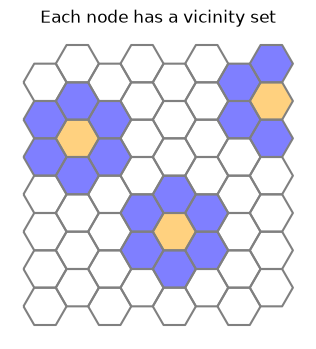

In [83]:
seed_points['cell_id'] = seed_points['id'].apply(lambda s: numeric_id(s))

# Anastassia's code for VNS plot
fig, ax = plt.subplots(1,1, figsize = (4,4))
seed_points.boundary.plot(ax=ax, color = "grey")
for i in [(7.0, 11.0), (4.0, 4.0), (1.0, 9.0)]:
    seed_points[seed_points.cell_id==i].plot(ax=ax, color = "orange", alpha = 0.5)
    seed_points[seed_points.cell_id.isin(seed_points.loc[seed_points.cell_id==i, "vns"].values[0])].plot(ax=ax, color = "blue", alpha = 0.5)
ax.set_axis_off()
ax.set_title("Each node has a vicinity set")
plt.show()

In [55]:
# Find next nodes of the routes

paths

{0: {'first_node': (0.0, 6.0)},
 1: {'first_node': (0.0, 2.0)},
 2: {'first_node': (7.0, 11.0)},
 3: {'first_node': (7.0, 13.0)},
 4: {'first_node': (3.0, 13.0)}}

In [56]:
print(seed_points.info())
seed_points.head()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   id            56 non-null     str     
 1   geometry      56 non-null     geometry
 2   centroid      56 non-null     geometry
 3   total_demand  56 non-null     float64 
 4   vns           56 non-null     object  
dtypes: float64(1), geometry(2), object(1), str(1)
memory usage: 2.5+ KB
None


,id,geometry,centroid,total_demand,vns
0,"0,0","POLYGON ((-5 -8.66025, 5 -8.66025, 10 0, 5 8.6...",POINT (1.4586e-16 0),55.549158,"[(1, 1), (1, -1), (0, -2), (-1, -1), (-1, 1), ..."
1,"1,1","POLYGON ((10 0, 20 0, 25 8.66025, 20 17.32051,...",POINT (15 8.66025),55.021649,"[(2, 2), (2, 0), (1, -1), (0, 0), (0, 2), (1, 3)]"
2,"2,0","POLYGON ((25 -8.66025, 35 -8.66025, 40 0, 35 8...",POINT (30 0),51.690439,"[(3, 1), (3, -1), (2, -2), (1, -1), (1, 1), (2..."
3,"3,1","POLYGON ((40 0, 50 0, 55 8.66025, 50 17.32051,...",POINT (45 8.66025),52.593630,"[(4, 2), (4, 0), (3, -1), (2, 0), (2, 2), (3, 3)]"
4,"4,0","POLYGON ((55 -8.66025, 65 -8.66025, 70 0, 65 8...",POINT (60 0),54.073770,"[(5, 1), (5, -1), (4, -2), (3, -1), (3, 1), (4..."


In [57]:
print(demand_matrix.info())
demand_matrix.head()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1540 entries, 0 to 1539
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   pair          1540 non-null   object  
 1   u             1540 non-null   str     
 2   v             1540 non-null   str     
 3   geometry      1540 non-null   geometry
 4   demand        1540 non-null   float64 
 5   demand_share  1540 non-null   float64 
dtypes: float64(2), geometry(1), object(1), str(2)
memory usage: 82.2+ KB
None


,pair,u,v,geometry,demand,demand_share
0,"(0,0, 1,1)","0,0","1,1","LINESTRING (1.4586e-16 0, 15 8.66025)",0.832448,0.054398
1,"(0,0, 2,0)","0,0","2,0","LINESTRING (1.4586e-16 0, 30 0)",0.855953,0.055934
2,"(0,0, 3,1)","0,0","3,1","LINESTRING (1.4586e-16 0, 45 8.66025)",0.937436,0.061259
3,"(0,0, 4,0)","0,0","4,0","LINESTRING (1.4586e-16 0, 60 0)",1.111994,0.072666
4,"(0,0, 5,1)","0,0","5,1","LINESTRING (1.4586e-16 0, 75 8.66025)",0.955629,0.062448


In [58]:
from typing import Dict, List, Tuple

# Gene: a path consisting of several edges
# Chromosome: a candidate solution (i.e. a network) consisting of genes
# Population: a collection of candidate solutions
# Generation: the population in a given iteration of the genetic algorithm

### TYPE ALIASES ###

type EdgeList = list[Tuple[int, int]]
type Gene = list[int] # the ints map to bit indexes in a chromosome
type Chromosome = int # each bit is an edge, identified by its bit index in the int
type Population = dict[Chromosome, float] # float for fitness function

### MAIN ###

def run(edges: EdgeList, demand: List[float], iterations: int) -> EdgeList:
    N = len(edges)
    total_demand = sum(demand)
    return _genetic_algorithm(iterations, N, demand, total_demand)
    # should the last population be returned to the user, or something else?

### VISUALISATION ##

def plot_network():
    """
    Visualises a chromosome as a network, including the percentage of demand covered.
    """

def plot_generation():
    """
    Creates a scatter plot of a generation, where each blob is a chromosome (network),
    the x axis is the total length of the network, and the y axis is the percentage of
    total demand covered.
    """

### ORCHESTRATOR ###

def _genetic_algorithm(iterations: int, N: int, demand: List[float], total_demand: float) -> Population:
    population = _initialise(N)
    for i in range(iterations): # or until some other convergence criteria
        evaluated = _evaluation(N, population, demand, total_demand)
        parents = _selection(evaluated)
        children = _evolution(parents)
        plot_generation(children)
        #_log_generation(children)
        population = children
    return population

### KEY FUNCTIONS ###

def _initialise(N: int) -> Population:
    """
    Generate a random selection of chromosomes for the first generation.
    """

def _evaluation(N: int, pop: Population, demand: List[float], total_demand: float) -> Population:
    """
    Calculates the percentage of demand covered for each chromosome in the population.
    """
    for c in pop:
        pop[c] = (fitness(N, c, demand) * 100) / total_demand
    return pop

def _selection():
    """
    Select parent chromosomes to breed the next generation, based on some survival probability.
    """

def _crossover():
    """
    Swap genes (sequences of edges) between parent chromosomes to create two child chromosomes.

    For each parent pair (inspired by Mesbah 2012):
    1. Assume that each parent is a connected network
    2. Determine shared vertices (edges) between the parents
    3. Randomly choose 1 shared vertex*
    4. Swap all edges that precede the selected shared vertex
    5. This produces 2 child solutions that are both connected

    *if no shared vertex exists, this parent pair doesn't produce new child solutions
    """

def _mutation():
    """
    Randomly add, remove or replace an edge

    For each ??? (inspired by Mesbah 2012):
    1. Determine the possible edge additions and removals that ensure connectedness
    2. Randomly choose 1 action from [add|remove|replace]
    3. Randomly choose 1 edge (from possible choices in step 1) to [add|remove|replace]
    """

def _evolution():
    """
    Create the next population.
    """

### HELPERS ###

def fitness(N: int, chromosome: Chromosome, demand: List[float]) -> float:
    acc_demand = 0.0
    for i in range(N):
        if edge_included(i, chromosome):
            acc_demand += demand[i]
    return acc_demand

def edge_included(pos: int, num: int) -> bool:
    mask = 1 << pos
    return (num & mask) != 0

def _mutate():
    """
    Randomly add, remove or replace an edge 
    """

def _reproduce():

#def _log_generation():

_IncompleteInputError: incomplete input (1250370299.py, line 119)